<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Bubble Plots**


Estimated time needed: **30** minutes


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 139.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 149.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 159.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


In [2]:
!pip install seaborn

import seaborn as sns

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  5.57MB/s    in 28s     

2026-09-29 08:08:15 (5.40 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


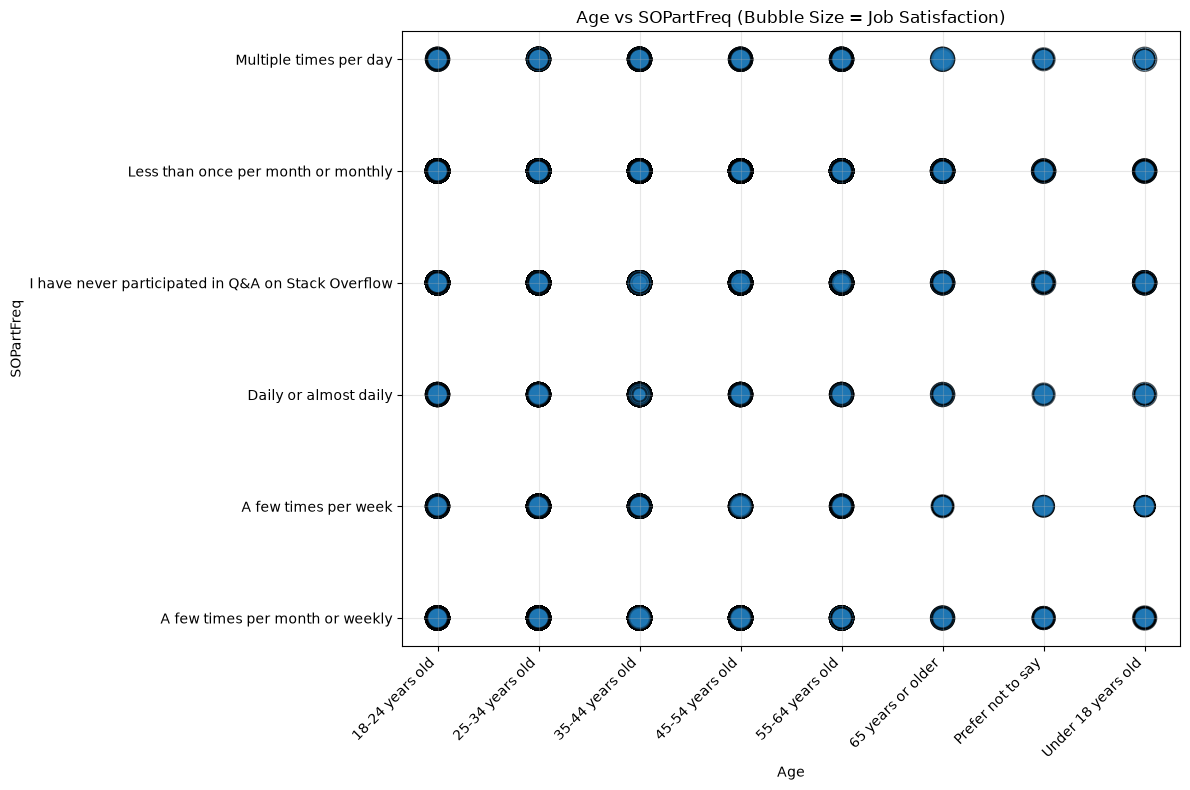

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a working dataframe
plot_df = df[["Age", "SOPartFreq", "JobSat"]].copy()

# Replace missing SOPartFreq values with the mode
sopartfreq_mode = plot_df["SOPartFreq"].mode()[0]
plot_df["SOPartFreq"] = plot_df["SOPartFreq"].fillna(sopartfreq_mode)

# Replace missing JobSat values with the mean
plot_df["JobSat"] = pd.to_numeric(plot_df["JobSat"], errors="coerce")
jobsat_mean = plot_df["JobSat"].mean()
plot_df["JobSat"] = plot_df["JobSat"].fillna(jobsat_mean)

# Remove rows with missing Age
plot_df = plot_df.dropna(subset=["Age"])

# Convert categorical variables to numeric codes for plotting
plot_df["AgeCode"] = pd.Categorical(plot_df["Age"]).codes
plot_df["SOPartFreqCode"] = pd.Categorical(plot_df["SOPartFreq"]).codes

# Store category labels
age_labels = list(pd.Categorical(plot_df["Age"]).categories)
sopartfreq_labels = list(pd.Categorical(plot_df["SOPartFreq"]).categories)

# Bubble plot
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df["AgeCode"],
    plot_df["SOPartFreqCode"],
    s=plot_df["JobSat"] * 30, # Bubble size represents JobSat
    alpha=0.6,
    edgecolors="black"
)

plt.title("Age vs SOPartFreq (Bubble Size = Job Satisfaction)")
plt.xlabel("Age")
plt.ylabel("SOPartFreq")

plt.xticks(
    range(len(age_labels)),
    age_labels,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(sopartfreq_labels)),
    sopartfreq_labels
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


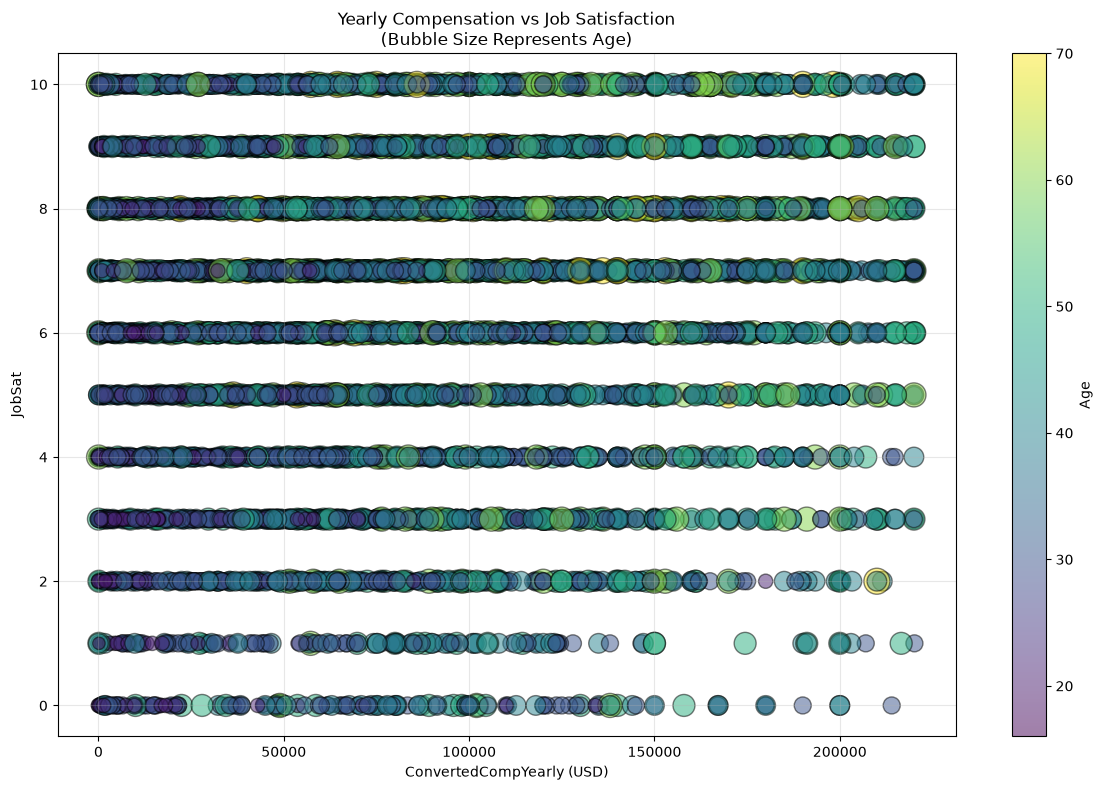

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create a working dataframe
plot_df = df[["ConvertedCompYearly", "JobSat", "Age"]].copy()

# Convert to numeric where necessary
plot_df["ConvertedCompYearly"] = pd.to_numeric(
    plot_df["ConvertedCompYearly"], errors="coerce"
)
plot_df["JobSat"] = pd.to_numeric(
    plot_df["JobSat"], errors="coerce"
)

# Remove rows with missing values
plot_df = plot_df.dropna(
    subset=["ConvertedCompYearly", "JobSat", "Age"]
)

# --------------------------------------------------
# Remove outliers from ConvertedCompYearly using IQR
# --------------------------------------------------
Q1 = plot_df["ConvertedCompYearly"].quantile(0.25)
Q3 = plot_df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_df = plot_df[
    (plot_df["ConvertedCompYearly"] >= lower_bound)
    & (plot_df["ConvertedCompYearly"] <= upper_bound)
]

# --------------------------------------------------
# Convert Age groups to numerical values for bubble size
# --------------------------------------------------
age_map = {
    "Under 18 years old": 16,
    "18-24 years old": 21,
    "25-34 years old": 30,
    "35-44 years old": 40,
    "45-54 years old": 50,
    "55-64 years old": 60,
    "65 years or older": 70
}

plot_df["AgeNumeric"] = plot_df["Age"].map(age_map)

# Remove rows where Age could not be mapped
plot_df = plot_df.dropna(subset=["AgeNumeric"])

# Bubble plot
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    plot_df["ConvertedCompYearly"],
    plot_df["JobSat"],
    s=plot_df["AgeNumeric"] * 5, # Bubble size represents Age
    alpha=0.5,
    c=plot_df["AgeNumeric"],
    cmap="viridis",
    edgecolors="black"
)

plt.colorbar(scatter, label="Age")

plt.title(
    "Yearly Compensation vs Job Satisfaction\n"
    "(Bubble Size Represents Age)"
)
plt.xlabel("ConvertedCompYearly (USD)")
plt.ylabel("JobSat")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



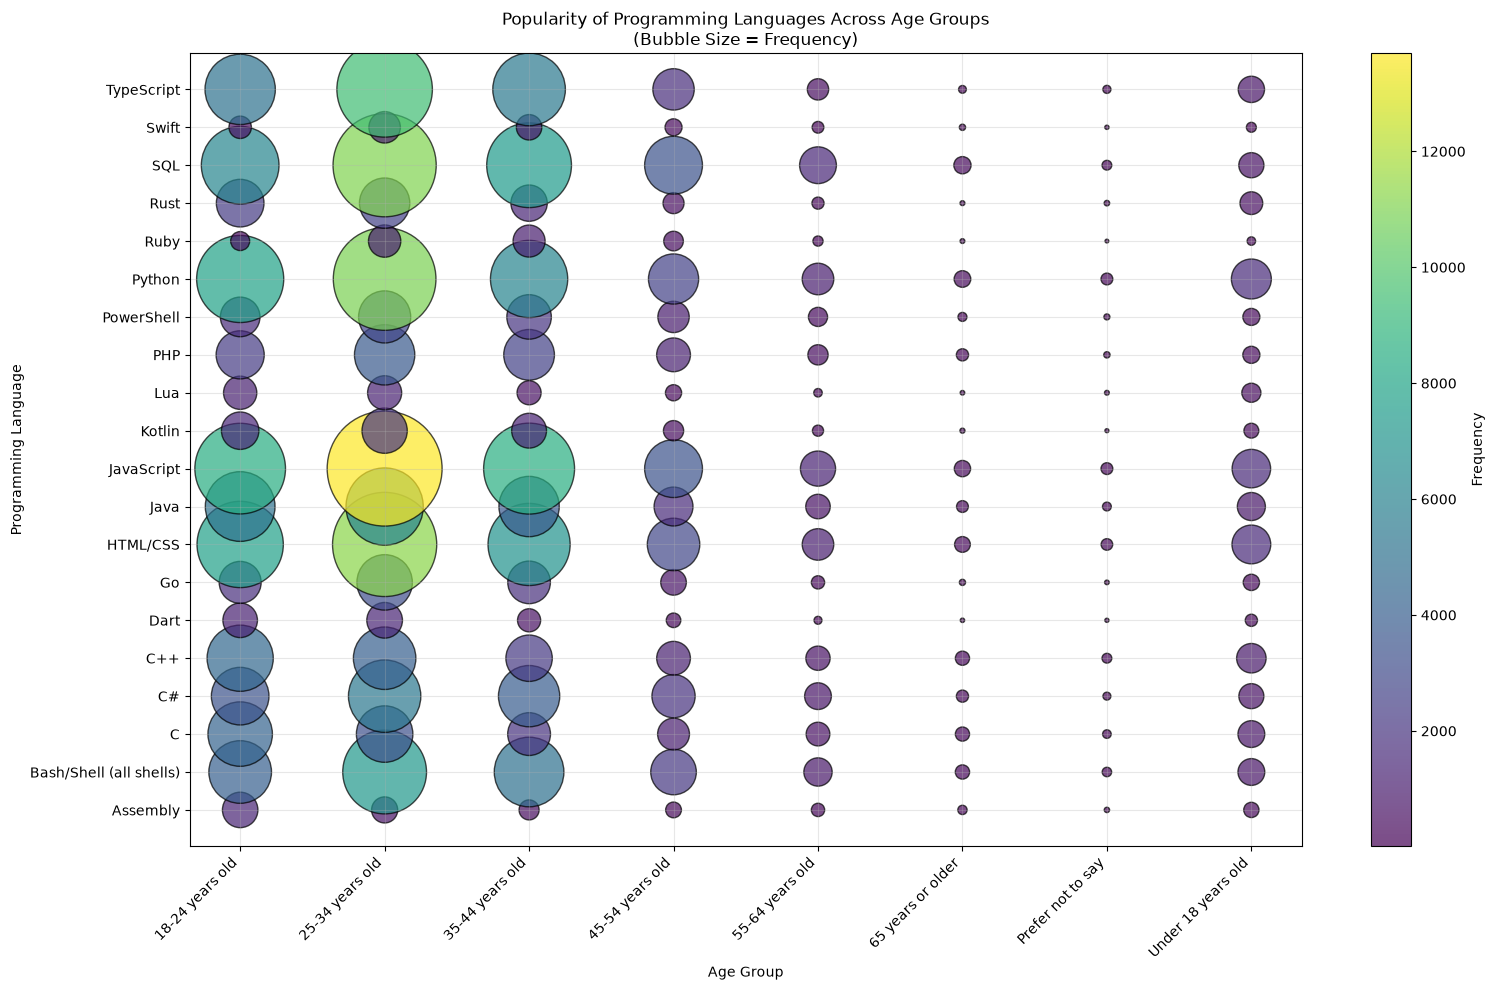

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Create working dataframe
plot_df = df[["Age", "LanguageHaveWorkedWith"]].copy()

# Remove missing values
plot_df = plot_df.dropna(subset=["Age", "LanguageHaveWorkedWith"])

# Split the semicolon-separated languages into individual rows
plot_df = plot_df.assign(
    Language=plot_df["LanguageHaveWorkedWith"].str.split(";")
).explode("Language")

# Count occurrences of each language by age group
lang_counts = (
    plot_df.groupby(["Age", "Language"])
    .size()
    .reset_index(name="Frequency")
)

# Optional: Keep only the top 20 most popular languages overall
top_languages = (
    lang_counts.groupby("Language")["Frequency"]
    .sum()
    .nlargest(20)
    .index
)

lang_counts = lang_counts[
    lang_counts["Language"].isin(top_languages)
]

# Convert categories to numeric positions for plotting
age_order = sorted(lang_counts["Age"].unique())
language_order = sorted(lang_counts["Language"].unique())

lang_counts["AgeCode"] = pd.Categorical(
    lang_counts["Age"],
    categories=age_order,
    ordered=True
).codes

lang_counts["LanguageCode"] = pd.Categorical(
    lang_counts["Language"],
    categories=language_order,
    ordered=True
).codes

# Create bubble plot
plt.figure(figsize=(16, 10))

scatter = plt.scatter(
    lang_counts["AgeCode"],
    lang_counts["LanguageCode"],
    s=lang_counts["Frequency"] * 0.5, # Bubble size = language frequency
    c=lang_counts["Frequency"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black"
)

plt.colorbar(scatter, label="Frequency")

plt.xticks(
    range(len(age_order)),
    age_order,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(language_order)),
    language_order
)

plt.xlabel("Age Group")
plt.ylabel("Programming Language")
plt.title(
    "Popularity of Programming Languages Across Age Groups\n"
    "(Bubble Size = Frequency)"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


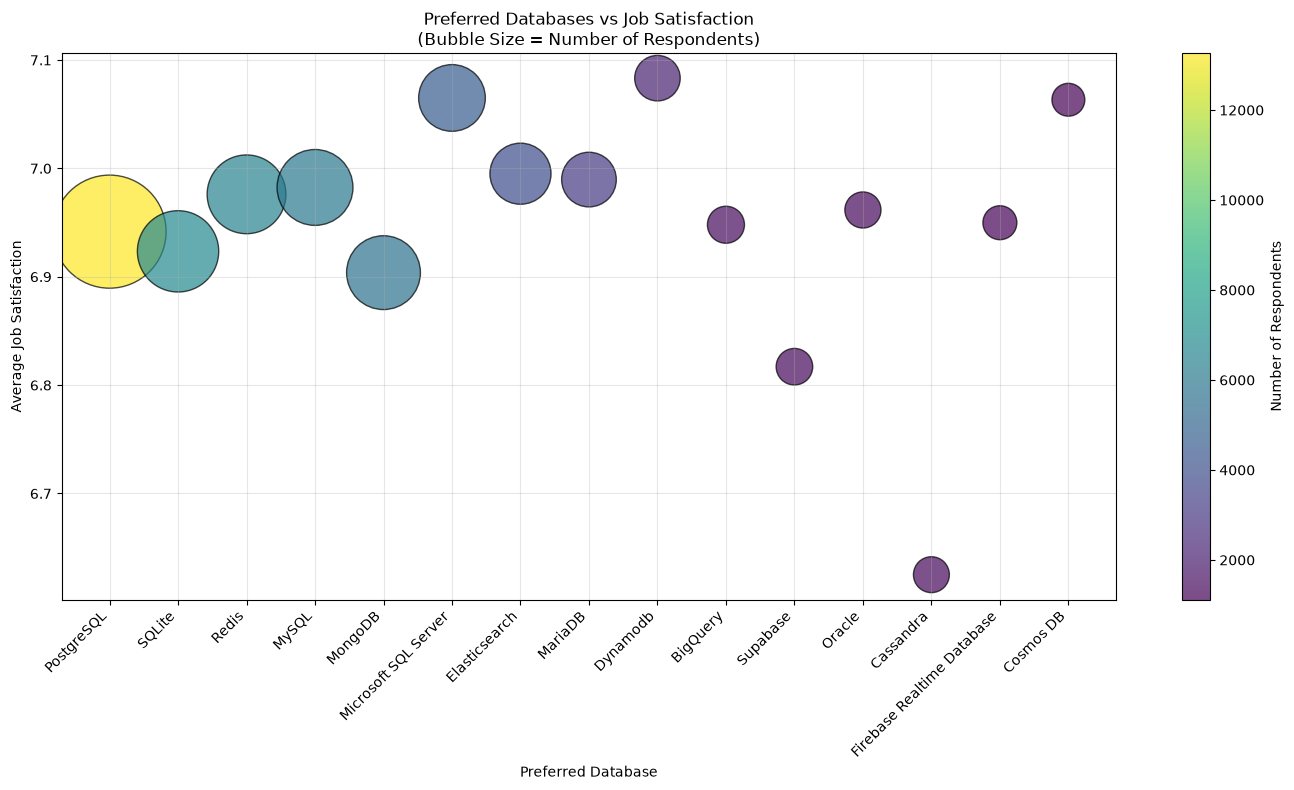

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Create working dataframe
plot_df = df[["DatabaseWantToWorkWith", "JobSat"]].copy()

# Convert JobSat to numeric
plot_df["JobSat"] = pd.to_numeric(plot_df["JobSat"], errors="coerce")

# Remove missing values
plot_df = plot_df.dropna(subset=["DatabaseWantToWorkWith", "JobSat"])

# Split multiple databases into separate rows
plot_df = plot_df.assign(
    Database=plot_df["DatabaseWantToWorkWith"].str.split(";")
).explode("Database")

# Remove extra spaces
plot_df["Database"] = plot_df["Database"].str.strip()

# Calculate respondent count and average job satisfaction per database
db_stats = (
    plot_df.groupby("Database")
    .agg(
    Respondents=("Database", "size"),
    AvgJobSat=("JobSat", "mean")
)
.reset_index()
)

# Keep only the top 15 databases by respondent count
top_dbs = (
    db_stats.sort_values("Respondents", ascending=False)
    .head(15)
)

# Create numeric positions for plotting
top_dbs["DatabaseCode"] = range(len(top_dbs))

# Bubble plot
plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    top_dbs["DatabaseCode"],
    top_dbs["AvgJobSat"],
    s=top_dbs["Respondents"] * 0.5, # Bubble size = respondent count
    c=top_dbs["Respondents"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black"
)

plt.colorbar(scatter, label="Number of Respondents")

plt.xticks(
    top_dbs["DatabaseCode"],
    top_dbs["Database"],
    rotation=45,
    ha="right"
)

plt.xlabel("Preferred Database")
plt.ylabel("Average Job Satisfaction")
plt.title(
    "Preferred Databases vs Job Satisfaction\n"
    "(Bubble Size = Number of Respondents)"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


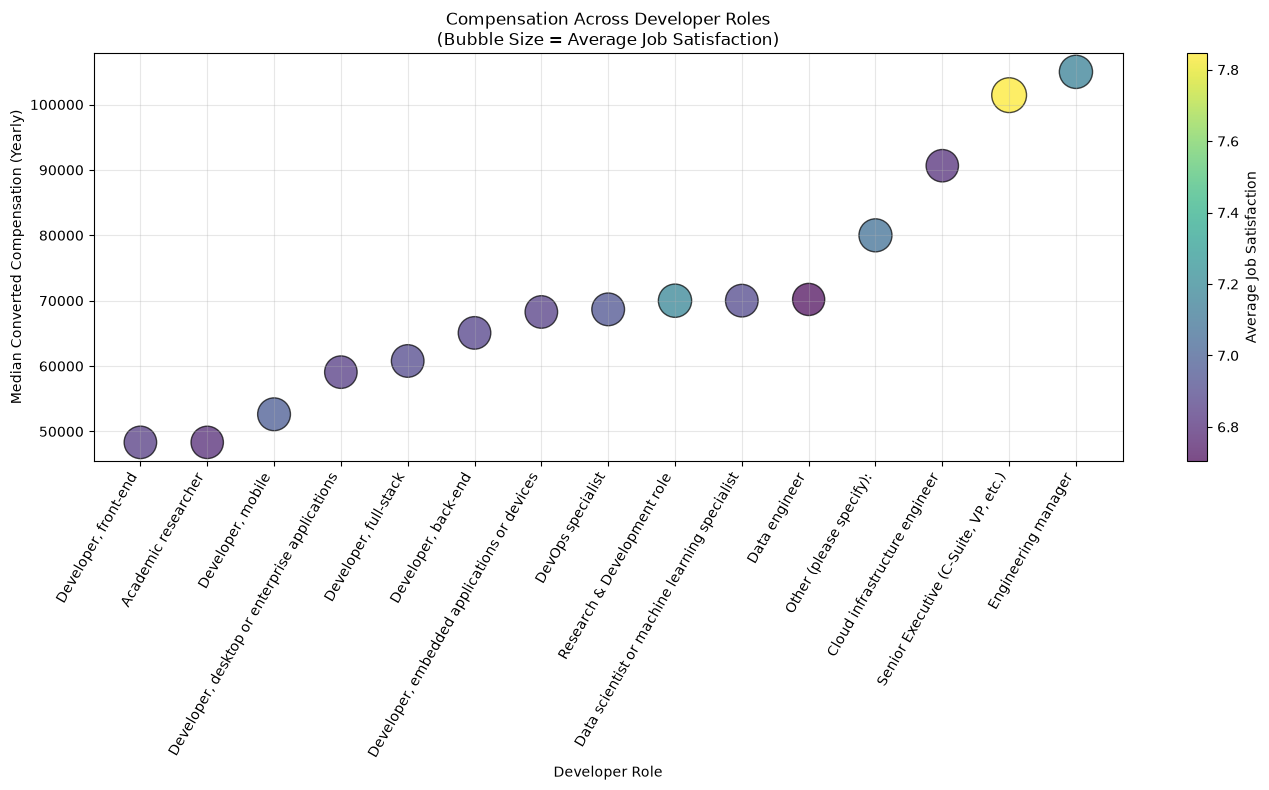

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Create working dataframe
plot_df = df[["ConvertedCompYearly", "DevType", "JobSat"]].copy()

# Convert fields to numeric
plot_df["ConvertedCompYearly"] = pd.to_numeric(
    plot_df["ConvertedCompYearly"], errors="coerce"
)
plot_df["JobSat"] = pd.to_numeric(
    plot_df["JobSat"], errors="coerce"
)

# Remove missing values
plot_df = plot_df.dropna(
    subset=["ConvertedCompYearly", "DevType", "JobSat"]
)

# --------------------------------------------------
# Remove compensation outliers using IQR
# --------------------------------------------------

Q1 = plot_df["ConvertedCompYearly"].quantile(0.25)
Q3 = plot_df["ConvertedCompYearly"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

plot_df = plot_df[
    (plot_df["ConvertedCompYearly"] >= lower_bound)
    & (plot_df["ConvertedCompYearly"] <= upper_bound)
]

# --------------------------------------------------
# Handle multiple developer roles
# --------------------------------------------------

plot_df = plot_df.assign(
    Role=plot_df["DevType"].str.split(";")
).explode("Role")

plot_df["Role"] = plot_df["Role"].str.strip()

# --------------------------------------------------
# Aggregate by developer role
# --------------------------------------------------

role_stats = (
    plot_df.groupby("Role")
    .agg(
        MedianComp=("ConvertedCompYearly", "median"),
        AvgJobSat=("JobSat", "mean"),
        Respondents=("Role", "size")
    )
    .reset_index()
)

# Top 15 roles by respondent count
role_stats = (
    role_stats.sort_values("Respondents", ascending=False)
    .head(15)
    .sort_values("MedianComp")
)

# Numeric positions for plotting
role_stats["RoleCode"] = range(len(role_stats))

# --------------------------------------------------
# Bubble Plot
# --------------------------------------------------
plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    role_stats["RoleCode"],
    role_stats["MedianComp"],
    s=role_stats["AvgJobSat"] * 80, # Bubble size = job satisfaction
    c=role_stats["AvgJobSat"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black"
)

plt.colorbar(scatter, label="Average Job Satisfaction")

plt.xticks(
    role_stats["RoleCode"],
    role_stats["Role"],
    rotation=60,
    ha="right"
)

plt.ylabel("Median Converted Compensation (Yearly)")
plt.xlabel("Developer Role")
plt.title(
    "Compensation Across Developer Roles\n"
    "(Bubble Size = Average Job Satisfaction)"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


/tmp/ipykernel_300/4247906293.py:50: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  tool_counts["Age"] = pd.Categorical(

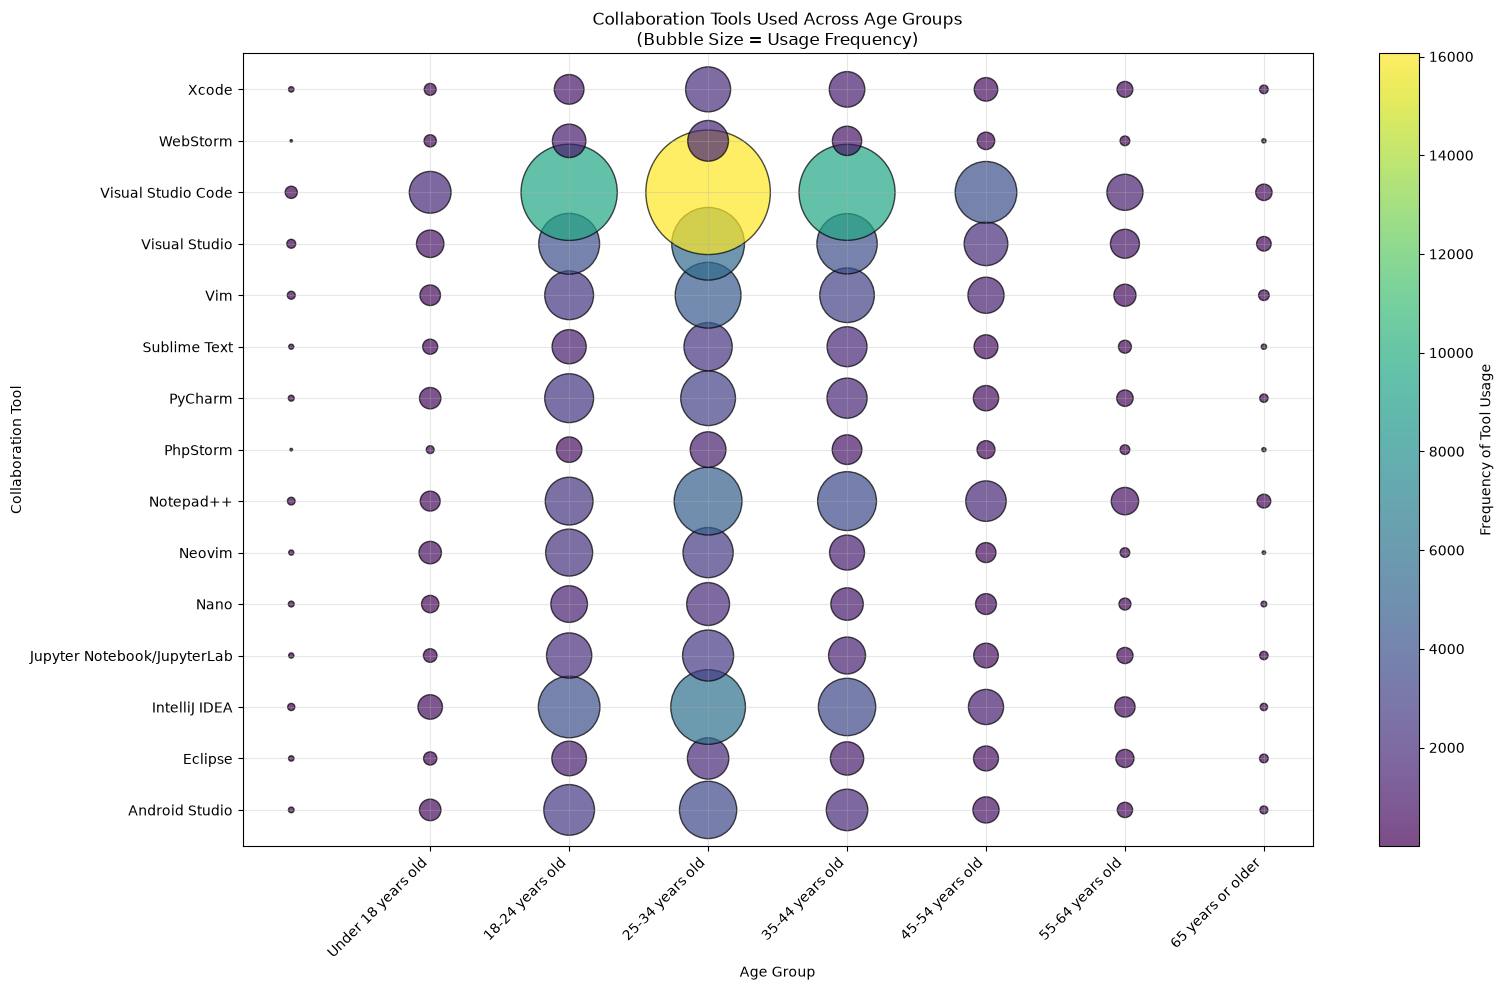

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# Create working dataframe
plot_df = df[["Age", "NEWCollabToolsHaveWorkedWith"]].copy()

# Remove missing values
plot_df = plot_df.dropna(
    subset=["Age", "NEWCollabToolsHaveWorkedWith"]
)

# Split multiple collaboration tools into separate rows
plot_df = plot_df.assign(
    Tool=plot_df["NEWCollabToolsHaveWorkedWith"].str.split(";")
).explode("Tool")

# Remove leading/trailing spaces
plot_df["Tool"] = plot_df["Tool"].str.strip()

# Count tool usage by age group
tool_counts = (
    plot_df.groupby(["Age", "Tool"])
    .size()
    .reset_index(name="Frequency")
)

# Keep only the top 15 tools overall
top_tools = (
    tool_counts.groupby("Tool")["Frequency"]
    .sum()
    .nlargest(15)
    .index
)

tool_counts = tool_counts[
    tool_counts["Tool"].isin(top_tools)
]

# Define age order
age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

tool_counts["Age"] = pd.Categorical(
    tool_counts["Age"],
    categories=age_order,
    ordered=True
)

# Create numeric positions
tool_counts["AgeCode"] = tool_counts["Age"].cat.codes

tool_order = sorted(tool_counts["Tool"].unique())

tool_counts["ToolCode"] = pd.Categorical(
    tool_counts["Tool"],
    categories=tool_order,
    ordered=True
).codes

# Bubble plot
plt.figure(figsize=(16, 10))

scatter = plt.scatter(
    tool_counts["AgeCode"],
    tool_counts["ToolCode"],
    s=tool_counts["Frequency"] * 0.5, # Bubble size = frequency
    c=tool_counts["Frequency"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black"
)

plt.colorbar(scatter, label="Frequency of Tool Usage")

plt.xticks(
    range(len(age_order)),
    age_order,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(tool_order)),
    tool_order
)

plt.xlabel("Age Group")
plt.ylabel("Collaboration Tool")
plt.title(
    "Collaboration Tools Used Across Age Groups\n"
    "(Bubble Size = Usage Frequency)"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



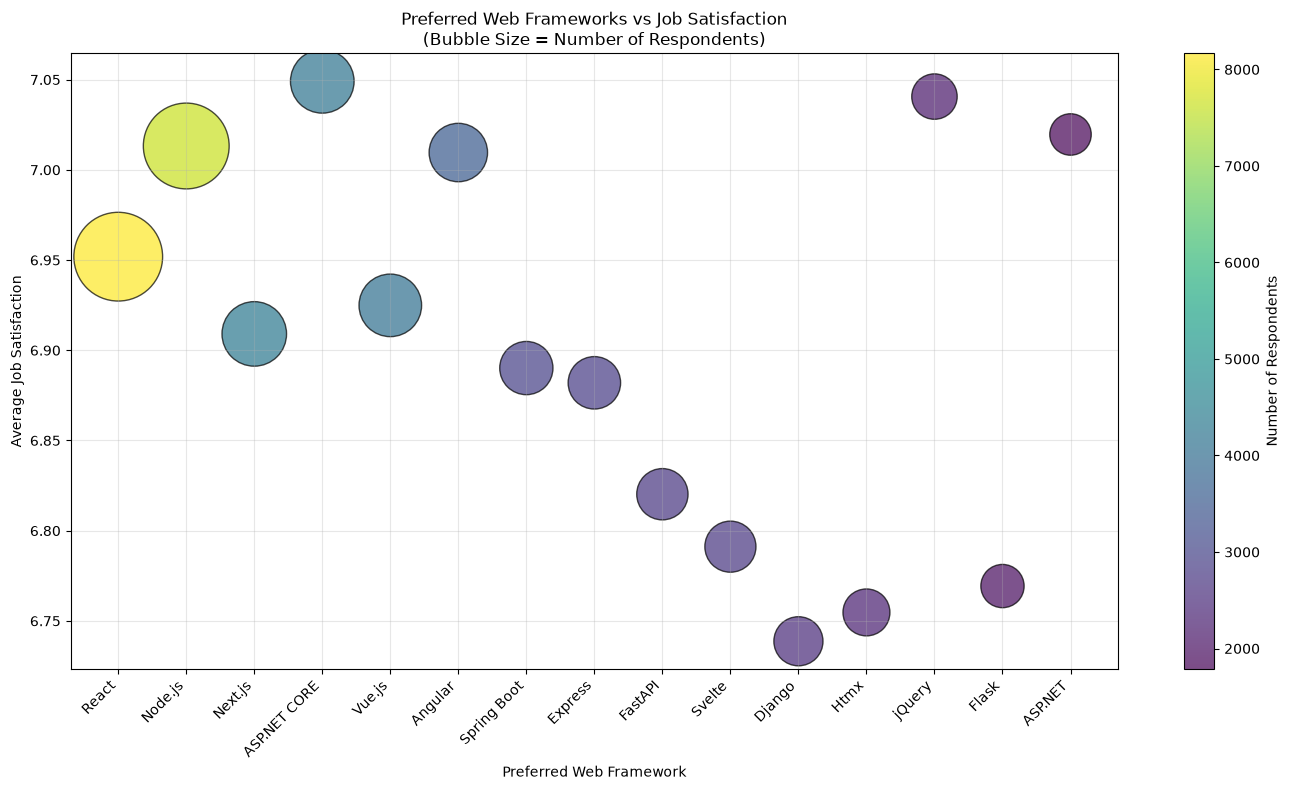

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Create working dataframe
plot_df = df[["WebframeWantToWorkWith", "JobSat"]].copy()

# Convert JobSat to numeric if it is already stored as numbers
plot_df["JobSat"] = pd.to_numeric(
    plot_df["JobSat"],
    errors="coerce"
)

# Remove missing values
plot_df = plot_df.dropna(
    subset=["WebframeWantToWorkWith", "JobSat"]
)

# Split multiple frameworks into separate rows
plot_df = plot_df.assign(
    Framework=plot_df["WebframeWantToWorkWith"].str.split(";")
).explode("Framework")

# Remove extra spaces
plot_df["Framework"] = plot_df["Framework"].str.strip()

# Calculate metrics for each framework
framework_stats = (
    plot_df.groupby("Framework")
    .agg(
        Respondents=("Framework", "size"),
        AvgJobSat=("JobSat", "mean")
    )
    .reset_index()
)

# Keep the top 15 frameworks by respondent count
framework_stats = (
    framework_stats
    .sort_values("Respondents", ascending=False)
    .head(15)
)

# Create x-axis positions
framework_stats["FrameworkCode"] = range(len(framework_stats))

# Bubble plot
plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    framework_stats["FrameworkCode"],
    framework_stats["AvgJobSat"],
    s=framework_stats["Respondents"] * 0.5, # Bubble size = respondent count
    c=framework_stats["Respondents"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black"
)

plt.colorbar(scatter, label="Number of Respondents")

plt.xticks(
    framework_stats["FrameworkCode"],
    framework_stats["Framework"],
    rotation=45,
    ha="right"
)

plt.xlabel("Preferred Web Framework")
plt.ylabel("Average Job Satisfaction")
plt.title(
    "Preferred Web Frameworks vs Job Satisfaction\n"
    "(Bubble Size = Number of Respondents)"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



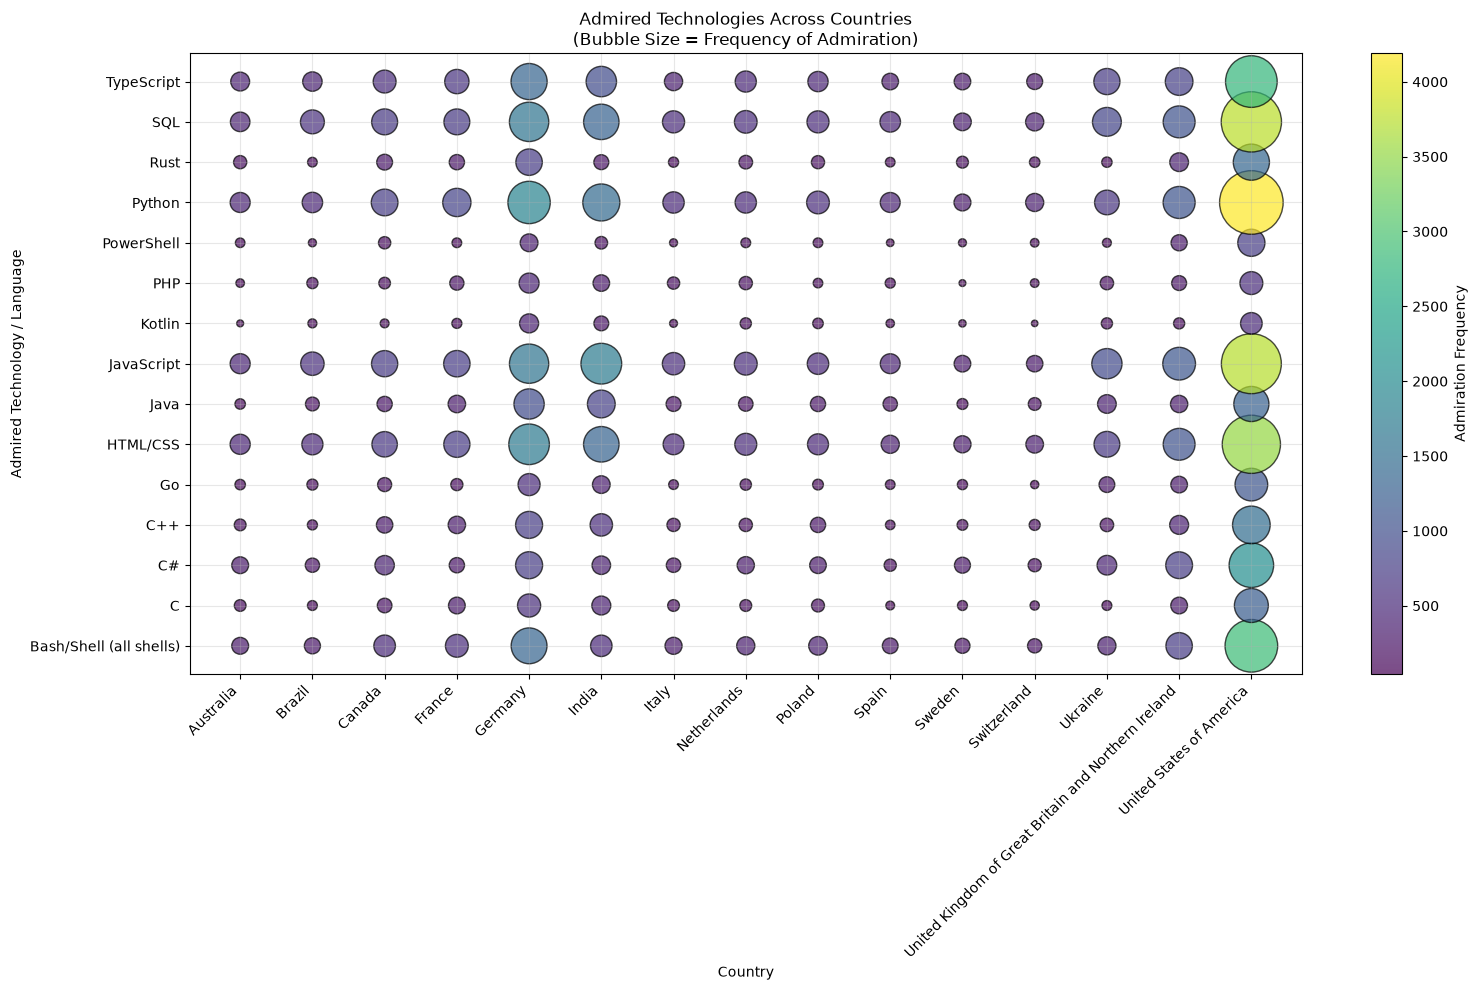

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Create working dataframe
plot_df = df[["Country", "LanguageAdmired"]].copy()

# Remove missing values
plot_df = plot_df.dropna(subset=["Country", "LanguageAdmired"])

# Split multiple admired languages into separate rows
plot_df = plot_df.assign(
    Language=plot_df["LanguageAdmired"].str.split(";")
).explode("Language")

# Remove extra spaces
plot_df["Language"] = plot_df["Language"].str.strip()

# Count admiration frequency by country and language
lang_counts = (
    plot_df.groupby(["Country", "Language"])
    .size()
    .reset_index(name="Frequency")
)

# Keep only the top 15 countries
top_countries = (
    lang_counts.groupby("Country")["Frequency"]
    .sum()
    .nlargest(15)
    .index
)

# Keep only the top 15 admired languages
top_languages = (
    lang_counts.groupby("Language")["Frequency"]
    .sum()
    .nlargest(15)
    .index
)

lang_counts = lang_counts[
    (lang_counts["Country"].isin(top_countries))
    & (lang_counts["Language"].isin(top_languages))
]

# Create numeric positions for plotting
country_order = sorted(lang_counts["Country"].unique())
language_order = sorted(lang_counts["Language"].unique())

lang_counts["CountryCode"] = pd.Categorical(
    lang_counts["Country"],
    categories=country_order,
    ordered=True
).codes

lang_counts["LanguageCode"] = pd.Categorical(
    lang_counts["Language"],
    categories=language_order,
    ordered=True
).codes

# Bubble plot
plt.figure(figsize=(16, 10))

scatter = plt.scatter(
    lang_counts["CountryCode"],
    lang_counts["LanguageCode"],
    s=lang_counts["Frequency"] * 0.5, # Bubble size = admiration frequency
    c=lang_counts["Frequency"],
    cmap="viridis",
    alpha=0.7,
    edgecolors="black"
)

plt.colorbar(scatter, label="Admiration Frequency")

plt.xticks(
    range(len(country_order)),
    country_order,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(language_order)),
    language_order
)

plt.xlabel("Country")
plt.ylabel("Admired Technology / Language")
plt.title(
    "Admired Technologies Across Countries\n"
    "(Bubble Size = Frequency of Admiration)"
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-29|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
